In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
if os.path.basename(os.getcwd()) == 'scripts_local':
    sys.path.insert(0, os.getcwd())

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from utils.plotting import apply_style, save_fig, COLOR_PALETTE
from utils.paths import CANONICAL_BOOKS_CSV, FIGURES_DIR

apply_style()
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)

In [2]:
canon = pd.read_csv(CANONICAL_BOOKS_CSV)

# authors and genres are stored as string repr of lists
def _parse_list(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except Exception:
        return [str(val)] if pd.notna(val) and str(val).strip() else []

canon['authors_list'] = canon['authors'].apply(_parse_list)
canon['genres_list'] = canon['genres'].apply(_parse_list)

print(f"Shape: {canon.shape}")
print(f"Columns: {list(canon.columns)}")

Shape: (10000, 40)
Columns: ['book_id', 'title', 'authors', 'original_publication_year', 'language_code', 'pages', 'description', 'genres', 'isbn10', 'isbn13', 'goodreads_book_id', 'average_rating', 'ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'asin', 'amazon_avg_rating', 'amazon_reviews_count', 'amazon_price', 'amazon_num_sellers', 'rank_best', 'rank_median', 'rank_latest', 'rank_observations', 'rank_time_in_top1k', 'rank_time_in_top10k', 'publisher', 'ucsd_format', 'ucsd_language_code', 'ucsd_num_pages', 'nyt_bestseller', 'nyt_best_rank', 'nyt_weeks_on_list', 'adapted_to_screen', 'authors_list', 'genres_list']


## 1  Column coverage

How complete is each column?  Columns from external joins will have significant gaps.

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_coverage.png


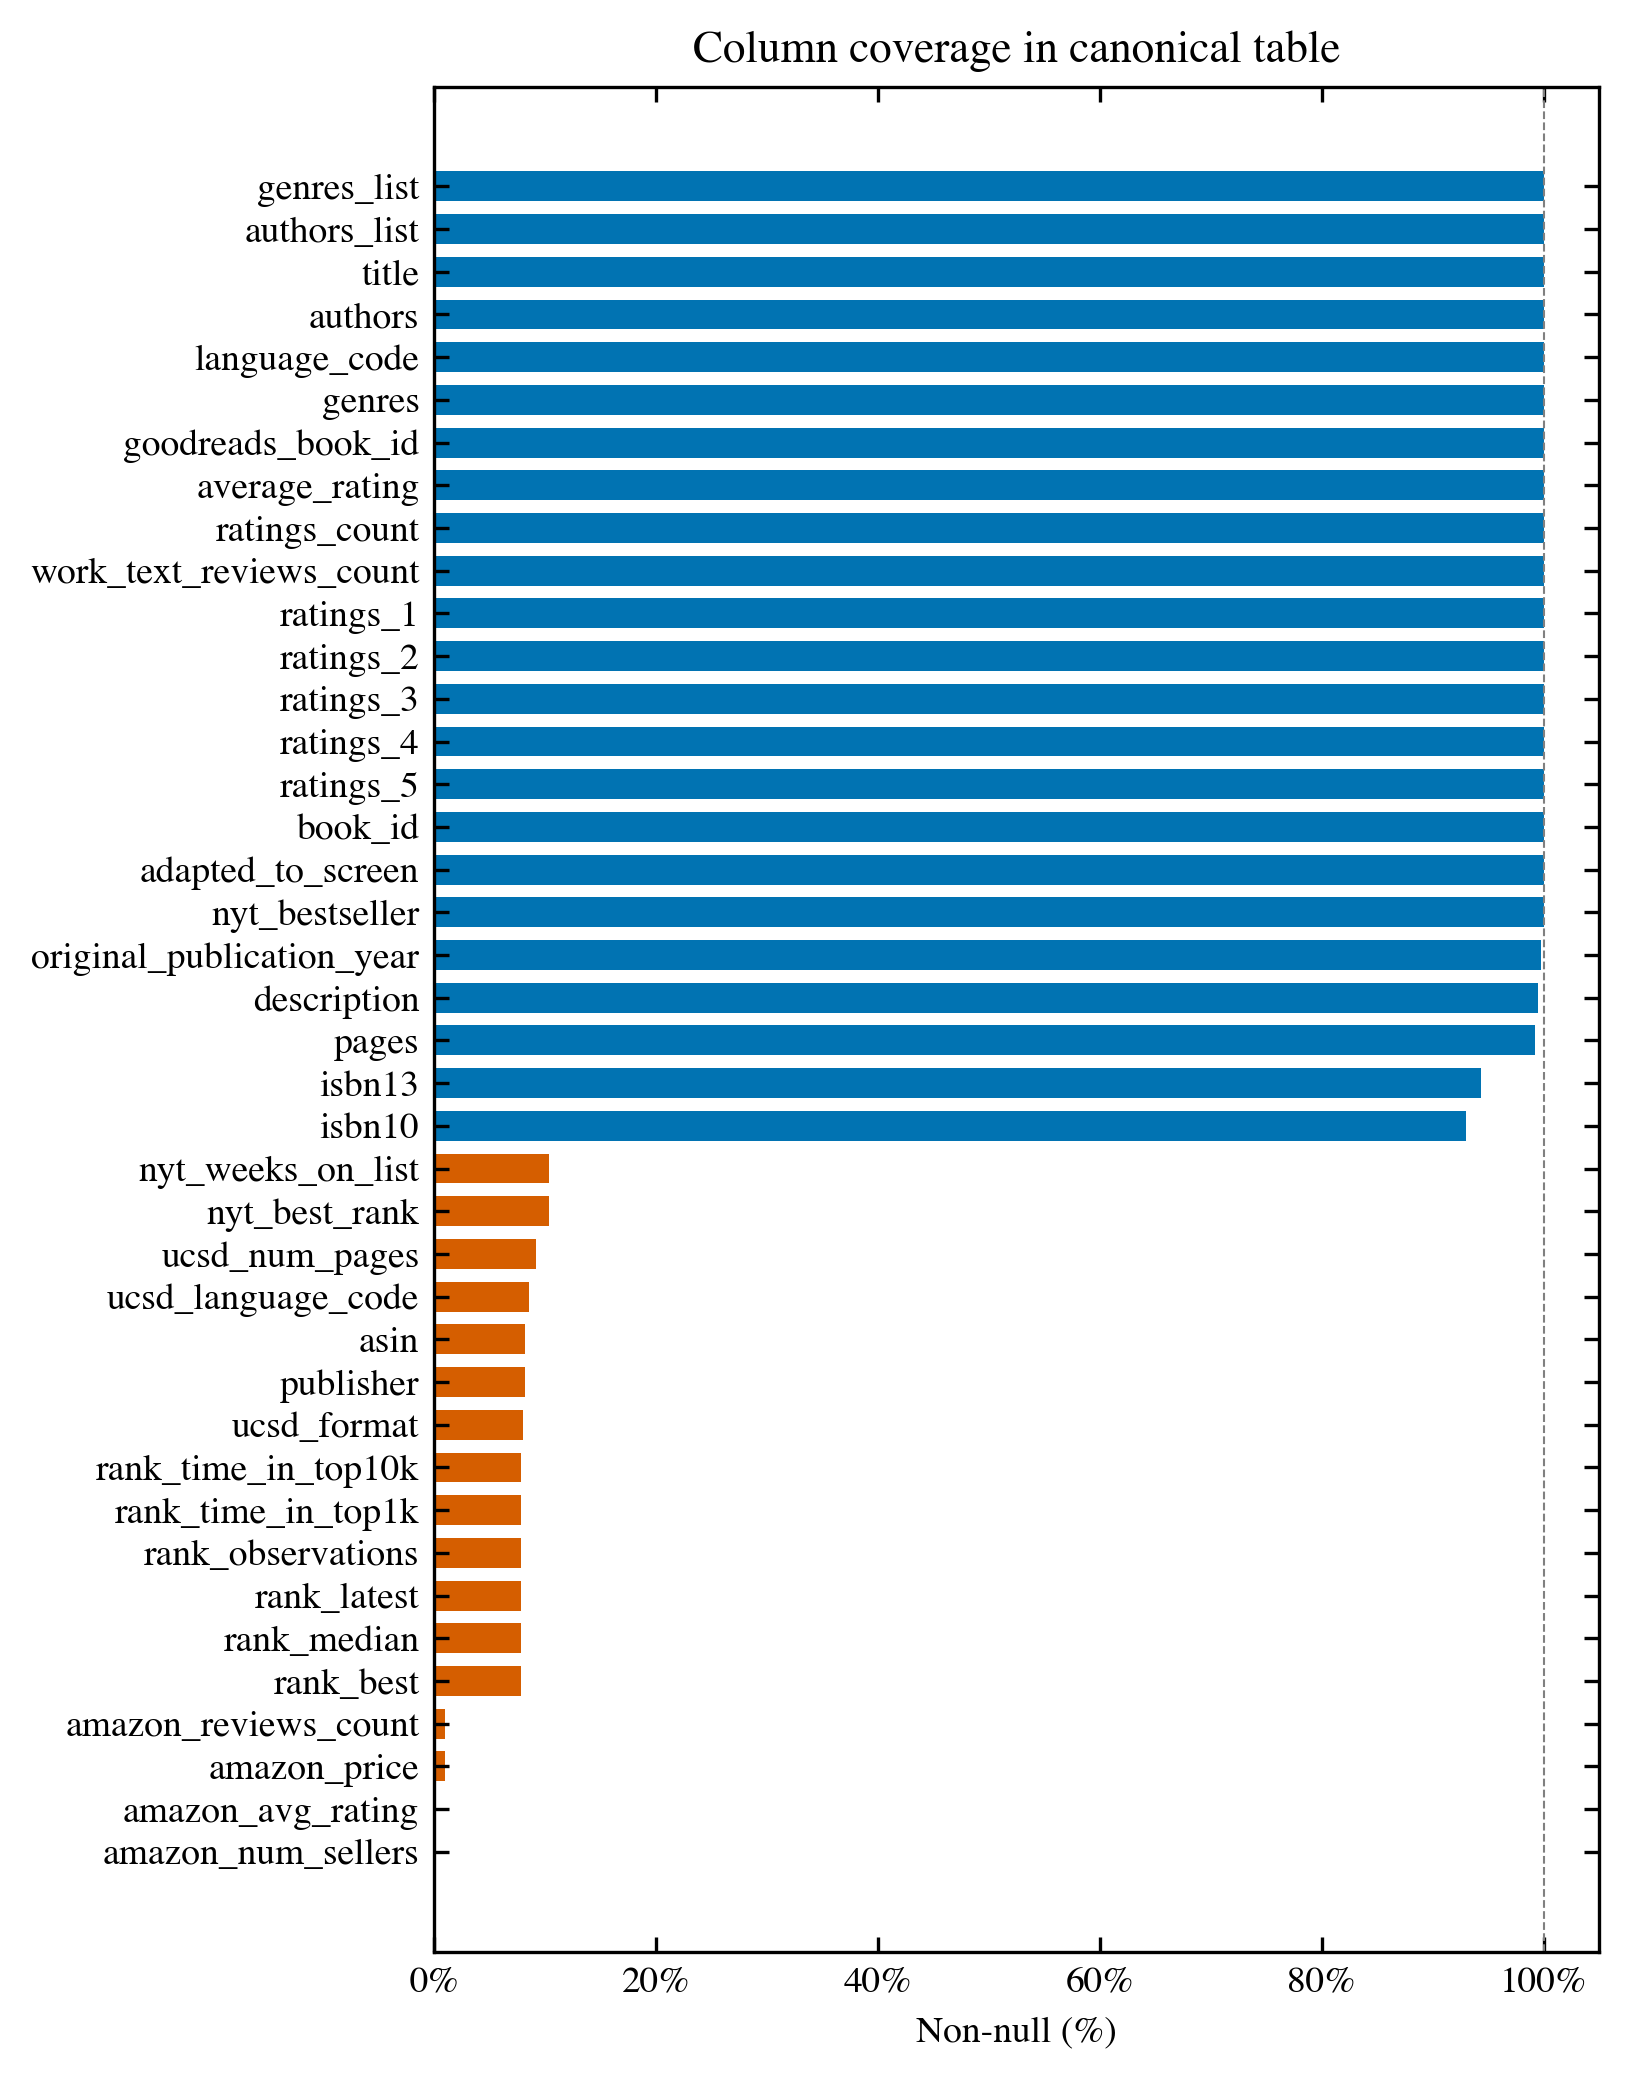

amazon_num_sellers             0.0%
amazon_avg_rating              0.0%
amazon_price                   1.0%
amazon_reviews_count           1.0%
rank_best                      7.8%
rank_median                    7.8%
rank_latest                    7.8%
rank_observations              7.8%
rank_time_in_top1k             7.8%
rank_time_in_top10k            7.8%
ucsd_format                    8.0%
publisher                      8.2%
asin                           8.2%
ucsd_language_code             8.6%
ucsd_num_pages                 9.2%
nyt_best_rank                 10.3%
nyt_weeks_on_list             10.3%
isbn10                        93.0%
isbn13                        94.3%
pages                         99.3%
description                   99.5%
original_publication_year     99.8%
nyt_bestseller               100.0%
adapted_to_screen            100.0%
book_id                      100.0%
ratings_5                    100.0%
ratings_4                    100.0%
ratings_3                   

In [3]:
# Coverage = fraction non-null
coverage = canon.notna().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(5.5, 7))
colors = [COLOR_PALETTE[0] if v >= 0.5 else COLOR_PALETTE[3] for v in coverage.values]
ax.barh(coverage.index, coverage.values * 100, color=colors, height=0.7)
ax.axvline(100, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('Non-null (%)')
ax.set_title('Column coverage in canonical table')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.tight_layout()
save_fig('03_coverage.png', FIGURES_DIR)
plt.show()

print(coverage.apply(lambda v: f'{v:.1%}').to_string())

## 2  Outcome labels

Class balance for `nyt_bestseller` and `adapted_to_screen`.

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_outcome_balance.png


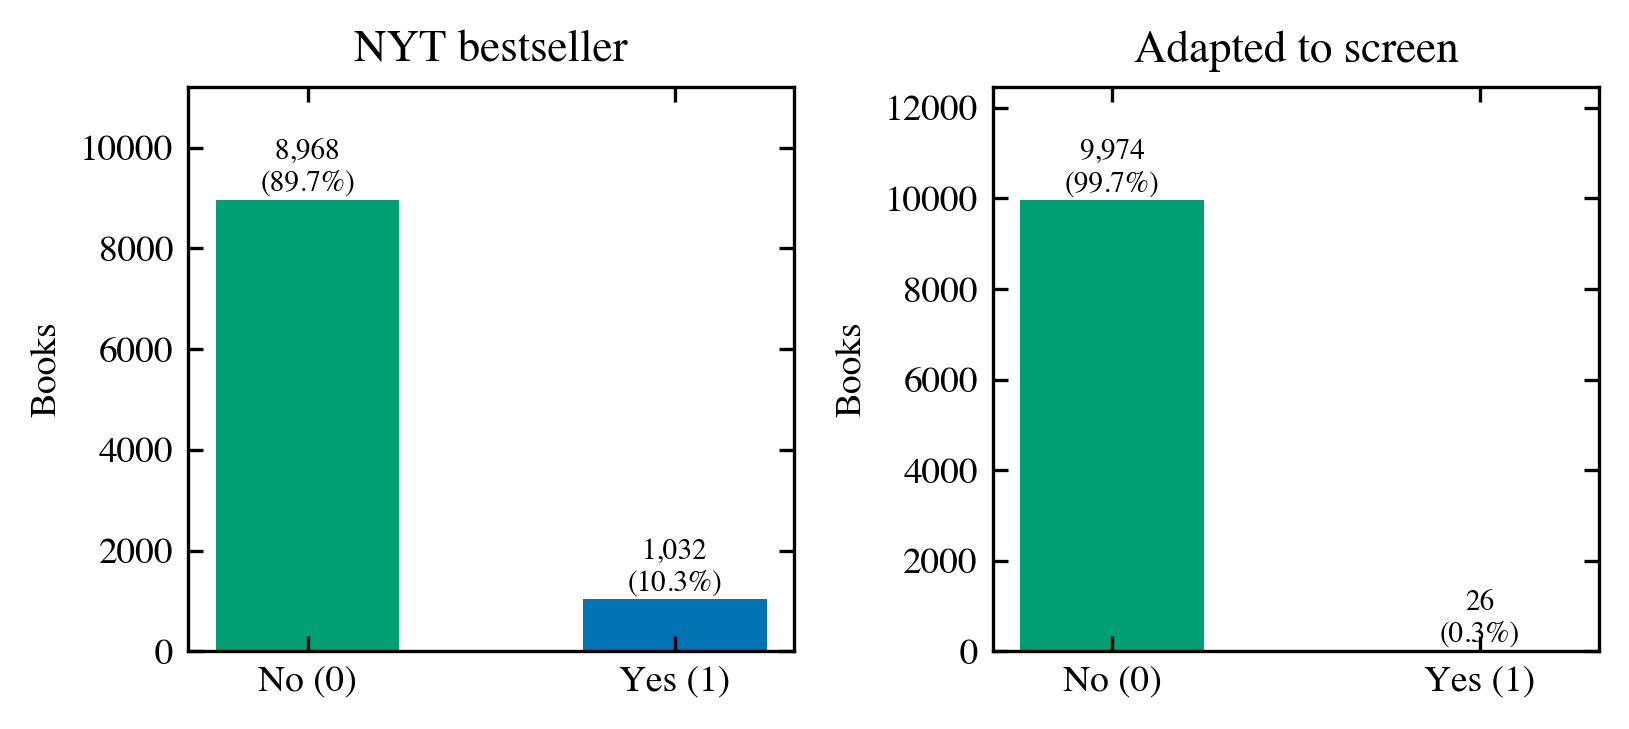

Both bestseller AND adapted: 10 (0.1%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

for ax, col, label in zip(axes,
                           ['nyt_bestseller', 'adapted_to_screen'],
                           ['NYT bestseller', 'Adapted to screen']):
    counts = canon[col].value_counts().sort_index()
    bars = ax.bar(['No (0)', 'Yes (1)'], counts.values,
                  color=[COLOR_PALETTE[2], COLOR_PALETTE[0]], width=0.5)
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{n:,}\n({n/len(canon):.1%})', ha='center', va='bottom', fontsize=7)
    ax.set_title(label)
    ax.set_ylabel('Books')
    ax.set_ylim(0, max(counts.values) * 1.25)

plt.tight_layout()
save_fig('03_outcome_balance.png', FIGURES_DIR)
plt.show()

# Overlap
both = (canon['nyt_bestseller'] == 1) & (canon['adapted_to_screen'] == 1)
print(f"Both bestseller AND adapted: {both.sum()} ({both.mean():.1%})")

## 3  Goodreads signals

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_goodreads_signals.png


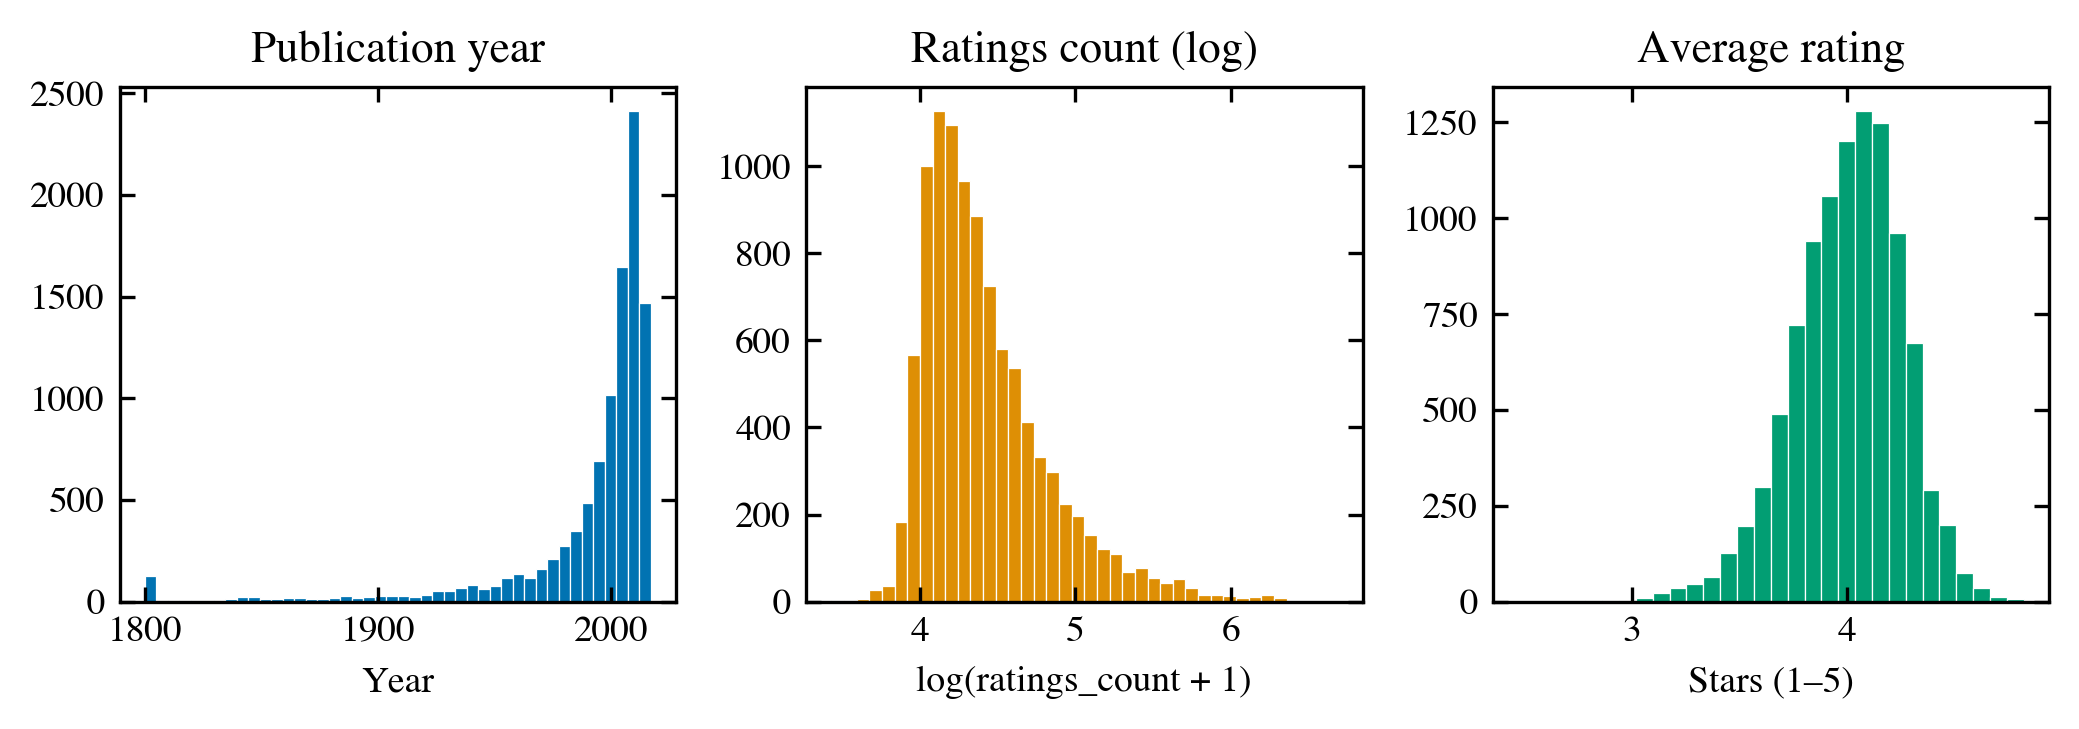

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

# Publication year
year = canon['original_publication_year'].dropna().clip(1800, 2020)
axes[0].hist(year, bins=44, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Publication year')
axes[0].set_xlabel('Year')

# Ratings count (log)
rc = canon['ratings_count']
axes[1].hist(np.log10(rc + 1), bins=40, color=COLOR_PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Ratings count (log)')
axes[1].set_xlabel('log(ratings_count + 1)')

# Average rating
axes[2].hist(canon['average_rating'].dropna(), bins=30,
             color=COLOR_PALETTE[2], edgecolor='white', linewidth=0.3)
axes[2].set_title('Average rating')
axes[2].set_xlabel('Stars (1–5)')

plt.tight_layout()
save_fig('03_goodreads_signals.png', FIGURES_DIR)
plt.show()

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_star_distribution.png


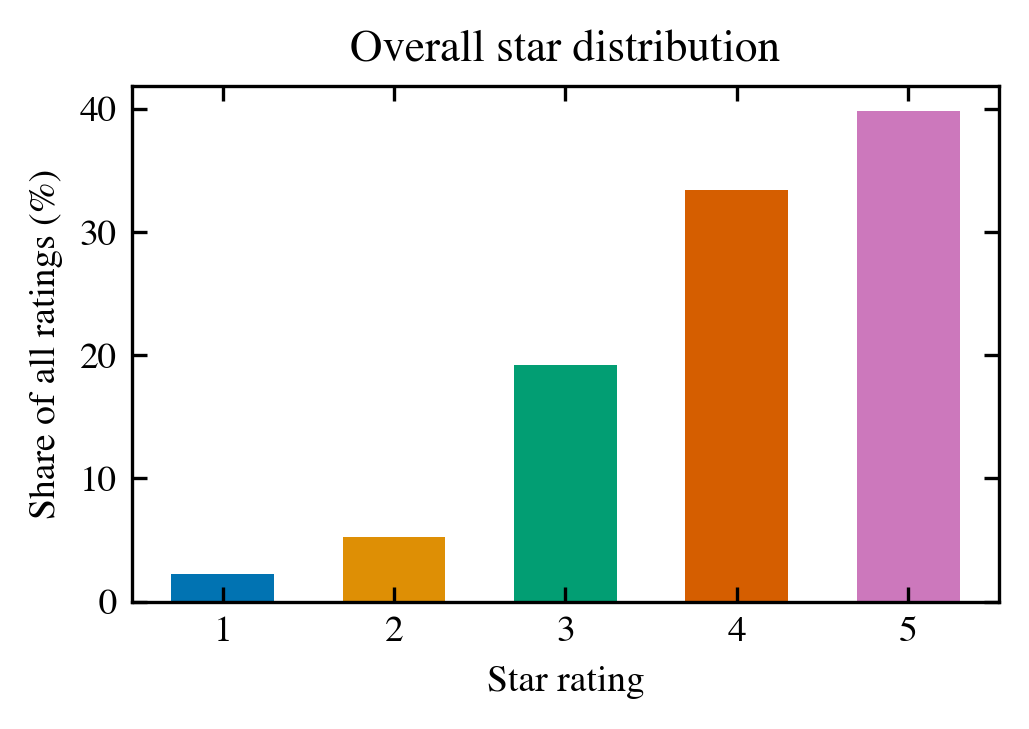

In [7]:
# Star-rating breakdown: fraction of ratings at each star level
star_cols = ['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']
star_totals = canon[star_cols].sum()
star_frac = star_totals / star_totals.sum()

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.bar([1, 2, 3, 4, 5], star_frac.values * 100, color=COLOR_PALETTE[:5], width=0.6)
ax.set_xlabel('Star rating')
ax.set_ylabel('Share of all ratings (%)')
ax.set_title('Overall star distribution')
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
save_fig('03_star_distribution.png', FIGURES_DIR)
plt.show()

## 4  Amazon rank features

Only ~8% of books have ASIN / rank history — plot only non-null rows.

Books with rank history: 783 (7.8%)
Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_rank_features.png


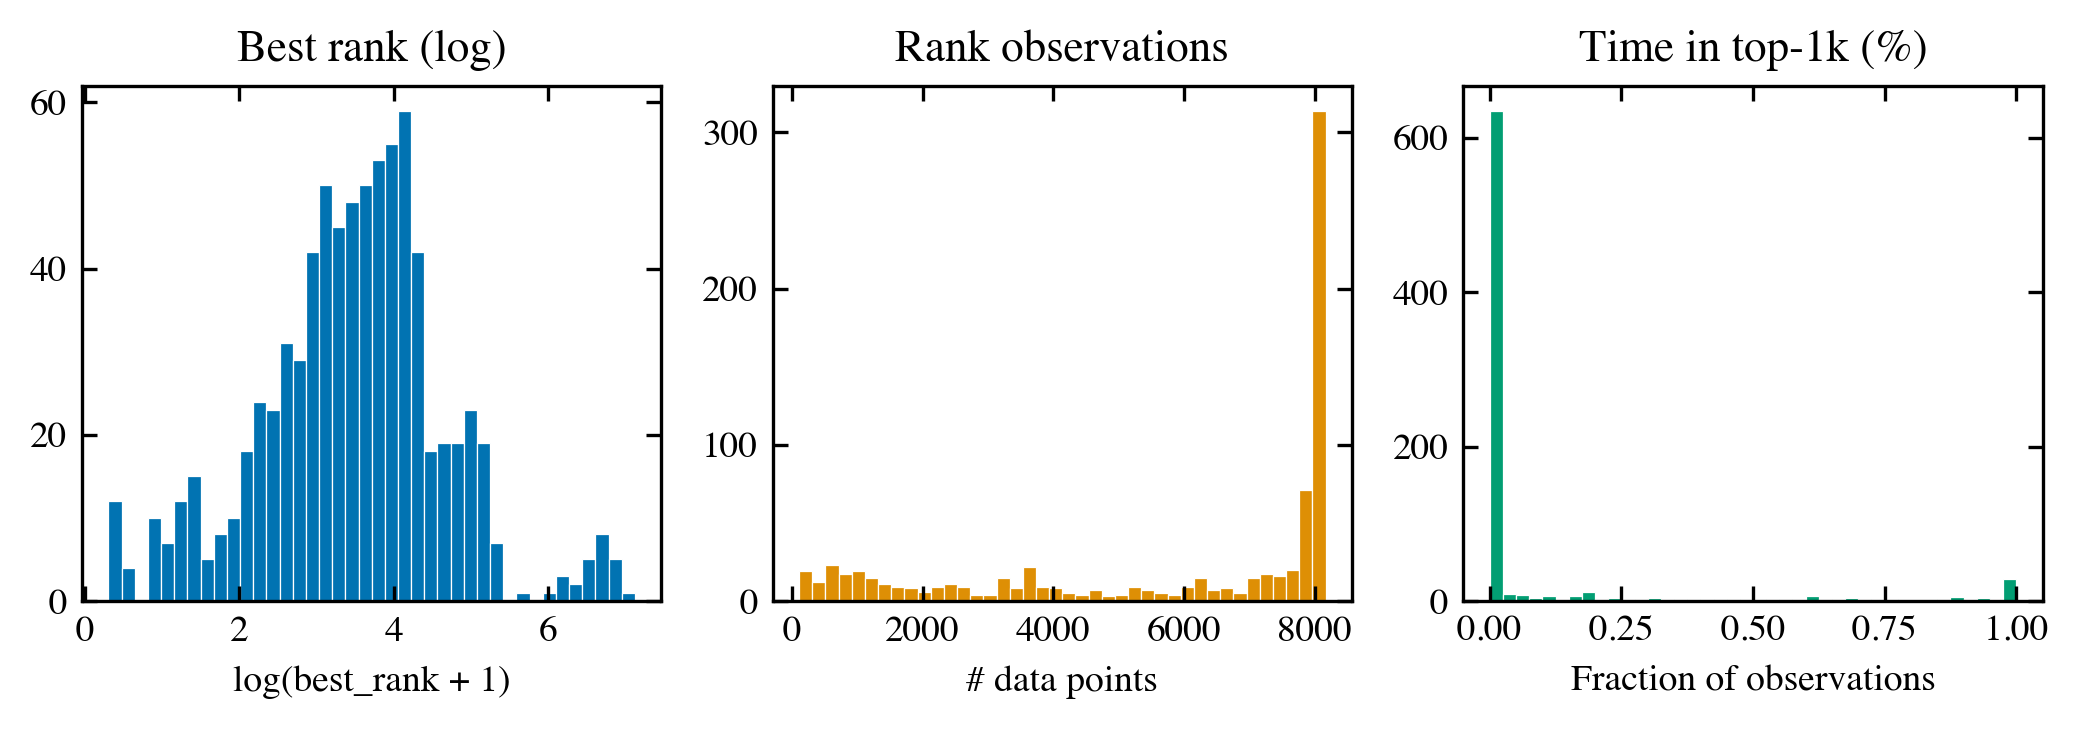

In [9]:
has_rank = canon.dropna(subset=['rank_best'])
print(f"Books with rank history: {len(has_rank):,} ({len(has_rank)/len(canon):.1%})")

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

axes[0].hist(np.log10(has_rank['rank_best'] + 1), bins=40,
             color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Best rank (log)')
axes[0].set_xlabel('log(best_rank + 1)')

axes[1].hist(has_rank['rank_observations'].dropna(), bins=40,
             color=COLOR_PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Rank observations')
axes[1].set_xlabel('# data points')

axes[2].hist(has_rank['rank_time_in_top1k'].dropna(), bins=40,
             color=COLOR_PALETTE[2], edgecolor='white', linewidth=0.3)
axes[2].set_title('Time in top-1k (%)')
axes[2].set_xlabel('Fraction of observations')

plt.tight_layout()
save_fig('03_rank_features.png', FIGURES_DIR)
plt.show()

With rank data — bestsellers: 128, non-bestsellers: 655
Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_rank_vs_bestseller.png


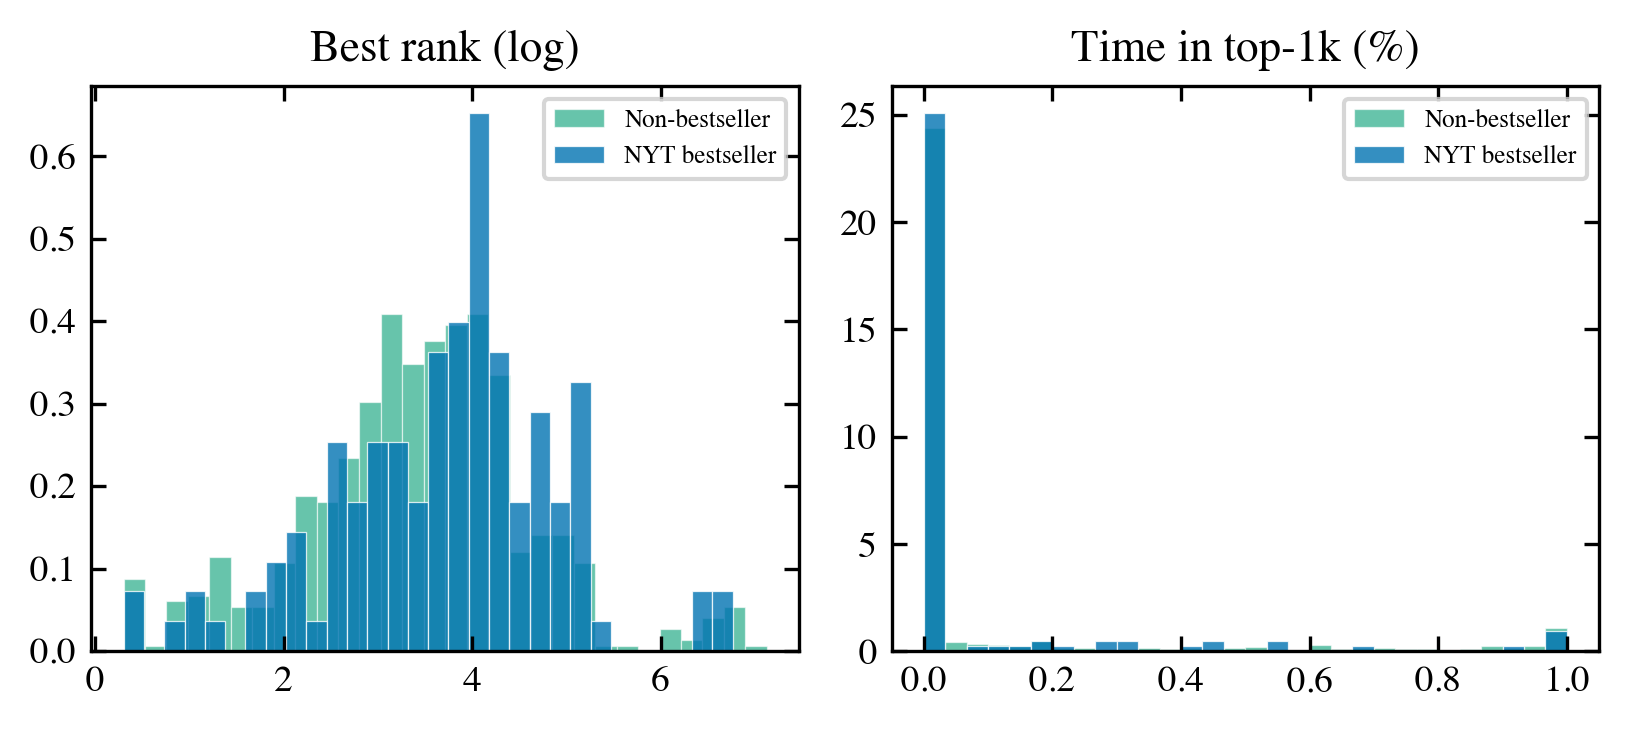

In [11]:
# Rank features: bestsellers vs. non-bestsellers (among books with rank data)
has_rank_bs = has_rank[has_rank['nyt_bestseller'] == 1]
has_rank_no = has_rank[has_rank['nyt_bestseller'] == 0]
print(f"With rank data — bestsellers: {len(has_rank_bs)}, non-bestsellers: {len(has_rank_no)}")

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

for ax, col, label in zip(axes,
                           ['rank_best', 'rank_time_in_top1k'],
                           ['Best rank (log)', 'Time in top-1k (%)']):
    vals_bs = np.log10(has_rank_bs[col].dropna() + 1) if col == 'rank_best' else has_rank_bs[col].dropna()
    vals_no = np.log10(has_rank_no[col].dropna() + 1) if col == 'rank_best' else has_rank_no[col].dropna()
    ax.hist(vals_no, bins=30, alpha=0.6, density=True, label='Non-bestseller',
            color=COLOR_PALETTE[2], edgecolor='white', linewidth=0.3)
    ax.hist(vals_bs, bins=30, alpha=0.8, density=True, label='NYT bestseller',
            color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.legend(fontsize=6)

plt.tight_layout()
save_fig('03_rank_vs_bestseller.png', FIGURES_DIR)
plt.show()

## 5  NYT bestseller profile

Among the 1,032 labelled bestsellers: how long did they stay on the list, and how high did they rank?

NYT bestsellers: 1032 (10.3%)
  With best-rank data: 1032
  With weeks data:     1032
Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_nyt_profile.png


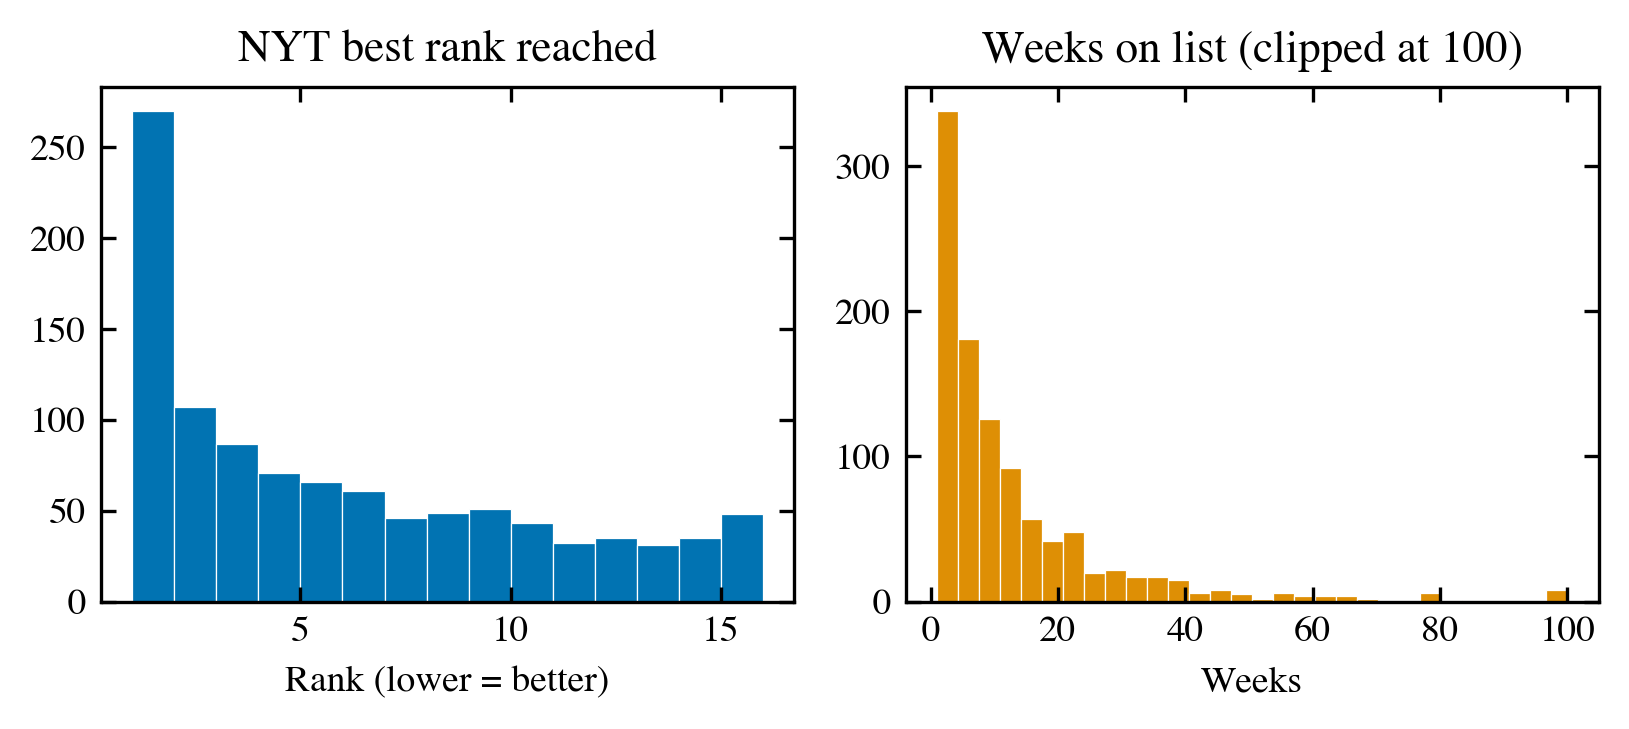


NYT weeks on list — summary:
count    1032.000000
mean       13.146318
std        17.256183
min         1.000000
25%         3.000000
50%         7.000000
75%        16.000000
max       178.000000
Name: nyt_weeks_on_list, dtype: float64


In [12]:
nyt = canon[canon['nyt_bestseller'] == 1].copy()
print(f"NYT bestsellers: {len(nyt)} ({len(nyt)/len(canon):.1%})")
print(f"  With best-rank data: {nyt['nyt_best_rank'].notna().sum()}")
print(f"  With weeks data:     {nyt['nyt_weeks_on_list'].notna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

axes[0].hist(nyt['nyt_best_rank'].dropna(), bins=15,
             color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('NYT best rank reached')
axes[0].set_xlabel('Rank (lower = better)')

axes[1].hist(nyt['nyt_weeks_on_list'].dropna().clip(upper=100), bins=30,
             color=COLOR_PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Weeks on list (clipped at 100)')
axes[1].set_xlabel('Weeks')

plt.tight_layout()
save_fig('03_nyt_profile.png', FIGURES_DIR)
plt.show()

print("\nNYT weeks on list — summary:")
print(nyt['nyt_weeks_on_list'].describe())

## 6  Genre analysis

In [13]:
from collections import Counter

# Top genres overall
all_genres = [g for gs in canon['genres_list'] for g in gs]
genre_counts = Counter(all_genres)
top_genres = [g for g, _ in genre_counts.most_common(20)]

# Bestseller rate per genre (minimum 50 books)
rows = []
for g in top_genres:
    mask = canon['genres_list'].apply(lambda gs: g in gs)
    subset = canon[mask]
    rows.append({
        'genre': g,
        'n_books': len(subset),
        'nyt_rate': subset['nyt_bestseller'].mean(),
        'adapted_rate': subset['adapted_to_screen'].mean(),
    })
genre_df = pd.DataFrame(rows).sort_values('n_books', ascending=False)

print(genre_df.to_string(index=False))

             genre  n_books  nyt_rate  adapted_rate
           fiction     8272  0.124637      0.002901
           fantasy     3746  0.044848      0.002136
           romance     3307  0.103719      0.002419
      contemporary     2918  0.186772      0.005141
       young-adult     2756  0.022496      0.003991
           mystery     2481  0.175333      0.003225
          classics     2110  0.103318      0.003791
          thriller     1822  0.211306      0.003293
historical-fiction     1793  0.204685      0.003346
        nonfiction     1641  0.004875      0.001219
             crime     1488  0.176075      0.001344
          suspense     1446  0.226833      0.002075
   science-fiction     1428  0.074230      0.002101
        paranormal     1308  0.050459      0.002294
         chick-lit     1266  0.174566      0.000790
            horror      876  0.128995      0.003425
           history      860  0.036047      0.002326
         biography      823  0.007290      0.002430
            

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_genre_analysis.png


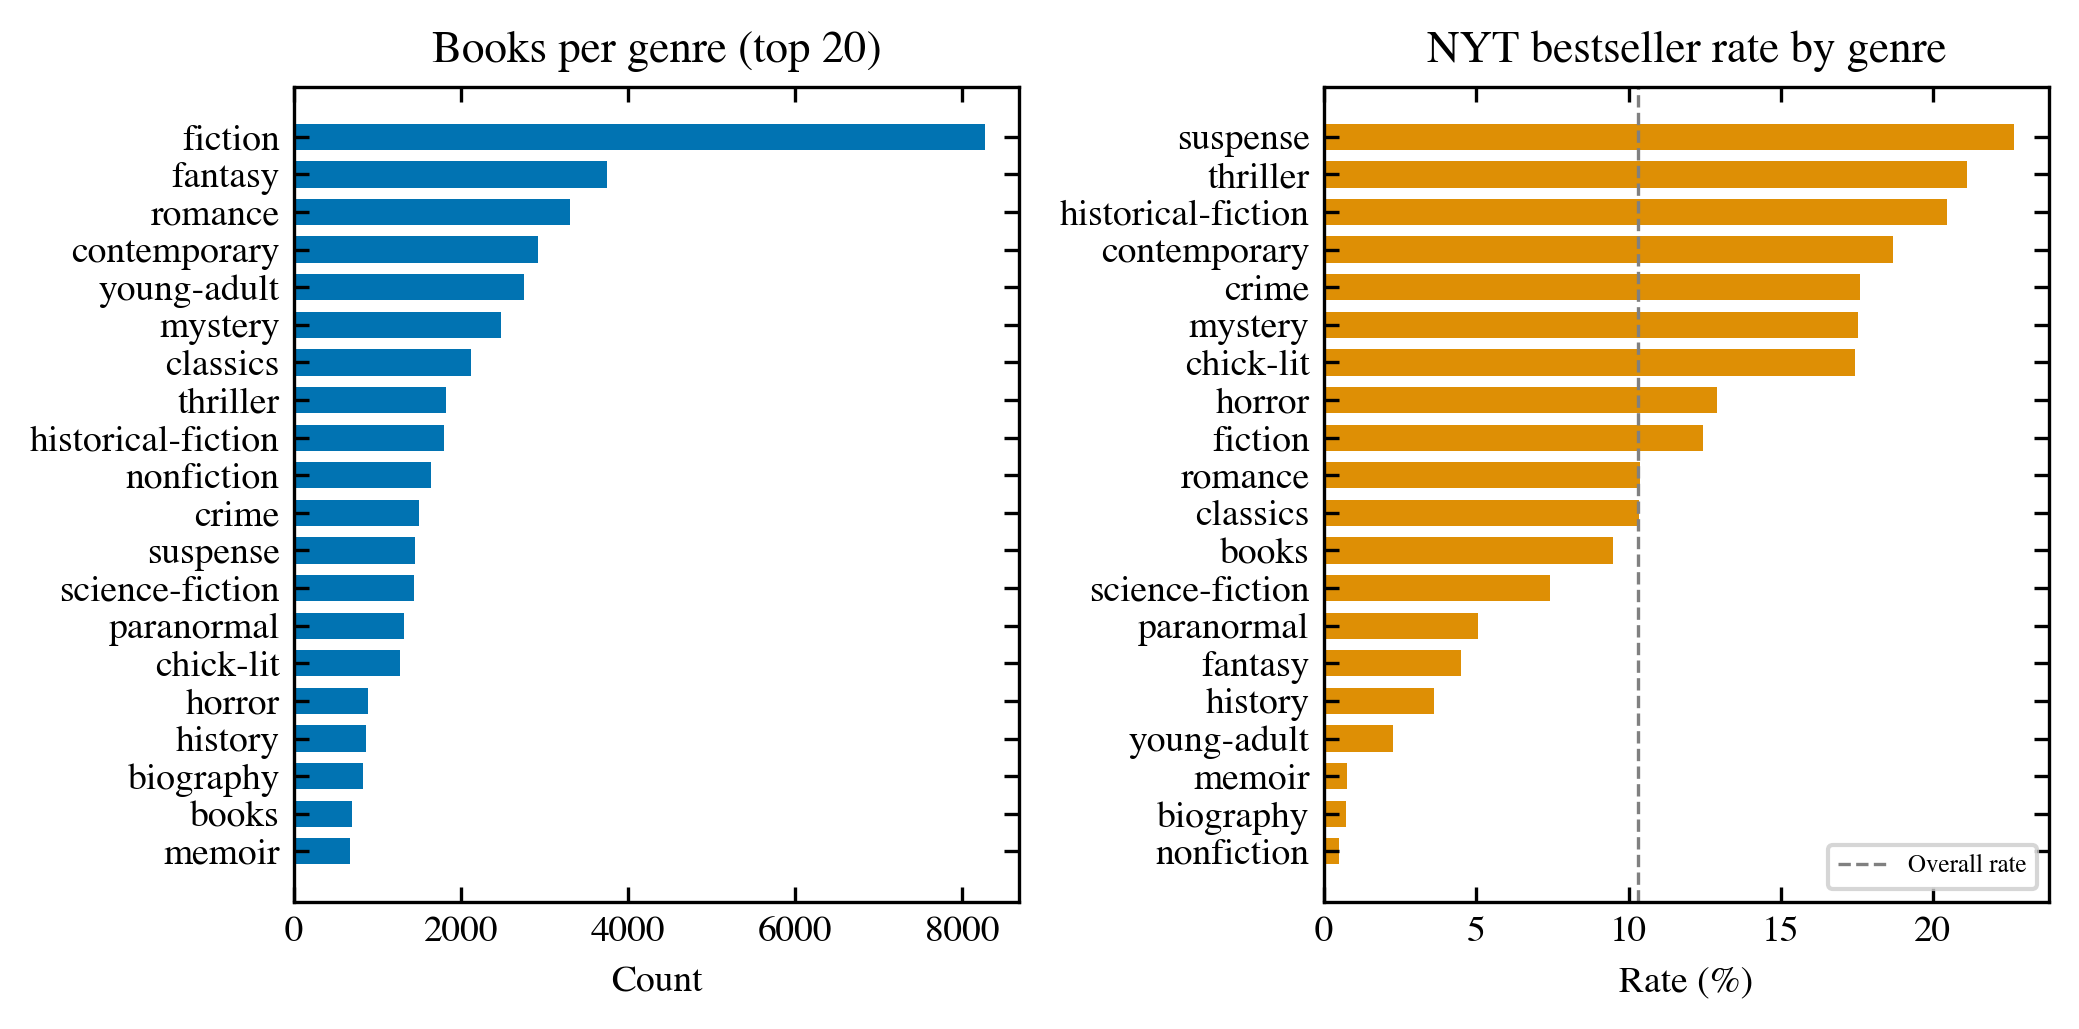

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

# Book counts per genre
gdf_sorted = genre_df.sort_values('n_books')
axes[0].barh(gdf_sorted['genre'], gdf_sorted['n_books'],
             color=COLOR_PALETTE[0], height=0.7)
axes[0].set_title('Books per genre (top 20)')
axes[0].set_xlabel('Count')

# NYT bestseller rate per genre
gdf_sorted_rate = genre_df.sort_values('nyt_rate')
axes[1].barh(gdf_sorted_rate['genre'], gdf_sorted_rate['nyt_rate'] * 100,
             color=COLOR_PALETTE[1], height=0.7)
axes[1].axvline(canon['nyt_bestseller'].mean() * 100, color='gray',
                linewidth=0.8, linestyle='--', label='Overall rate')
axes[1].set_title('NYT bestseller rate by genre')
axes[1].set_xlabel('Rate (%)')
axes[1].legend(fontsize=6)

plt.tight_layout()
save_fig('03_genre_analysis.png', FIGURES_DIR)
plt.show()

## 7  Feature correlation with nyt_bestseller

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_correlation_matrix.png


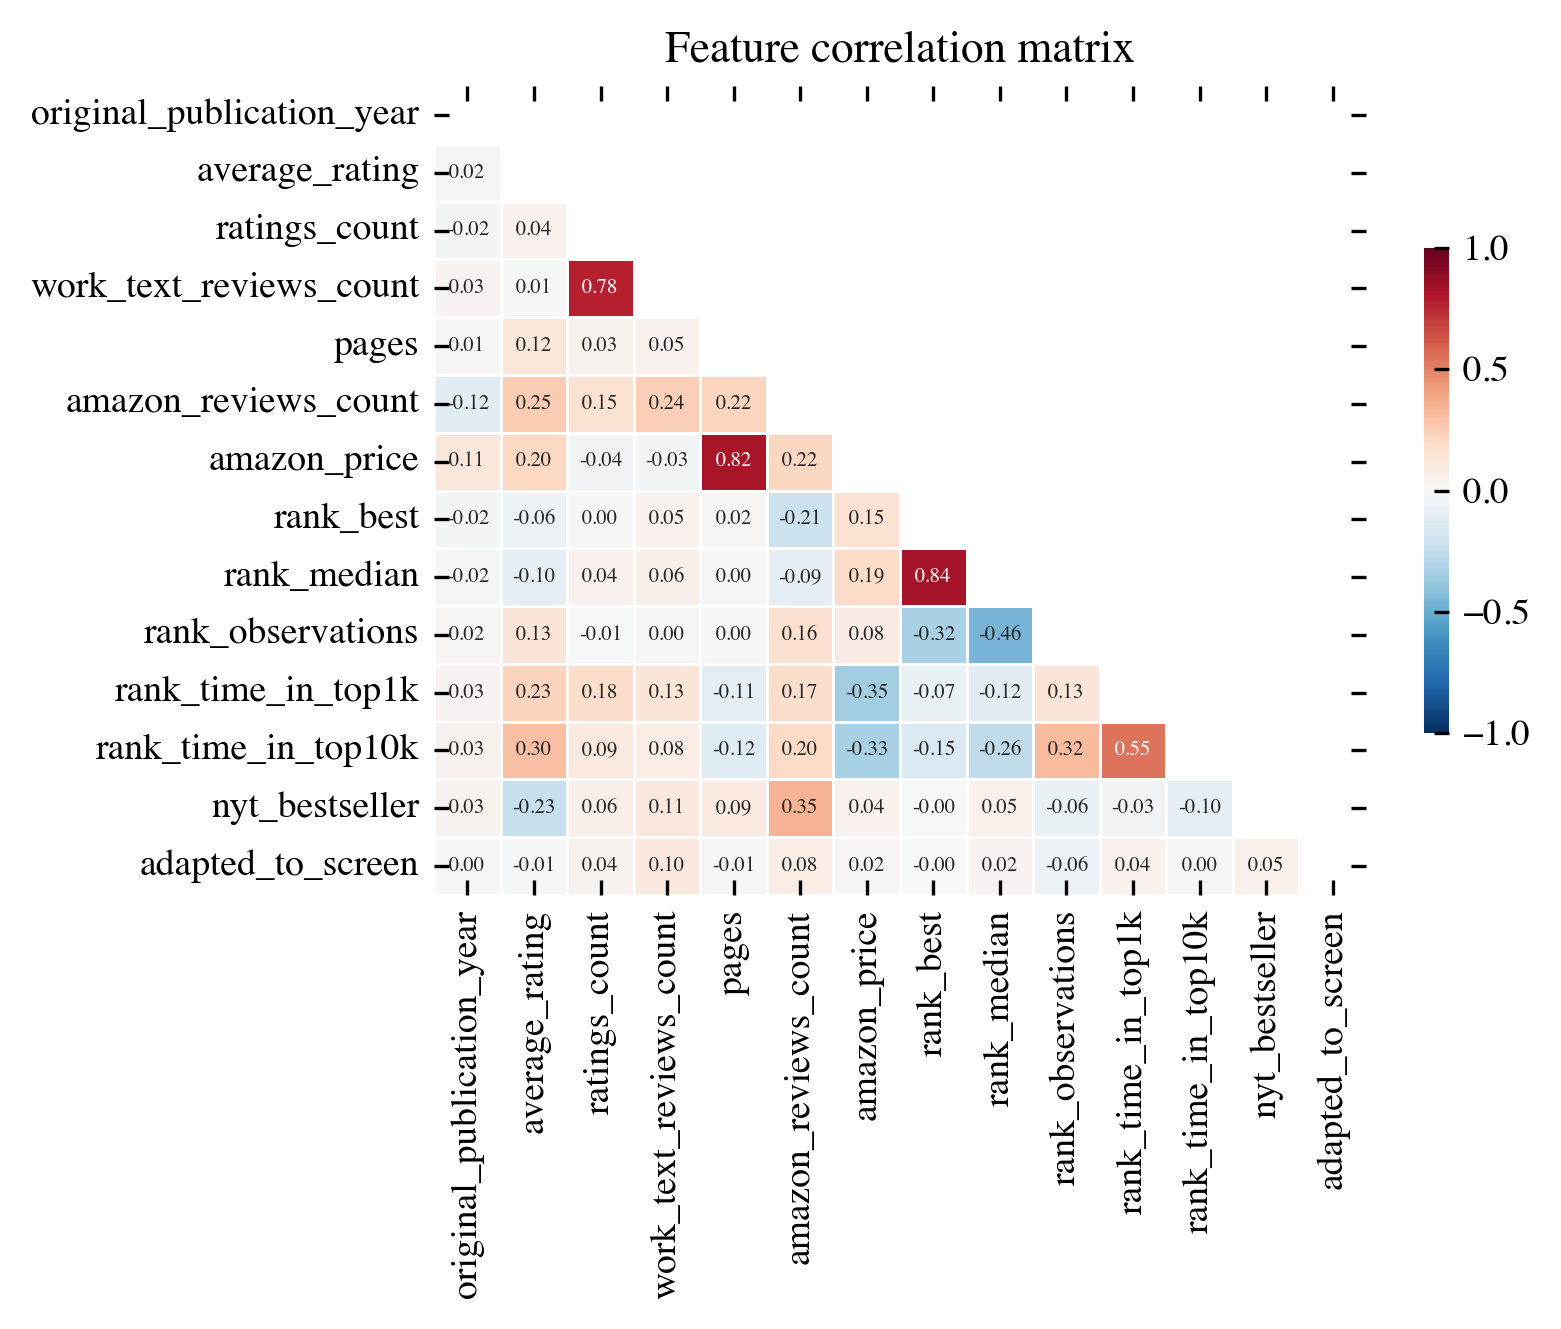

In [15]:
numeric_features = [
    'original_publication_year',
    'average_rating',
    'ratings_count',
    'work_text_reviews_count',
    'pages',
    'amazon_reviews_count',
    'amazon_price',
    'rank_best',
    'rank_median',
    'rank_observations',
    'rank_time_in_top1k',
    'rank_time_in_top10k',
    'nyt_bestseller',
    'adapted_to_screen',
]

corr = canon[numeric_features].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={'size': 5}, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
save_fig('03_correlation_matrix.png', FIGURES_DIR)
plt.show()

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_feature_target_corr.png


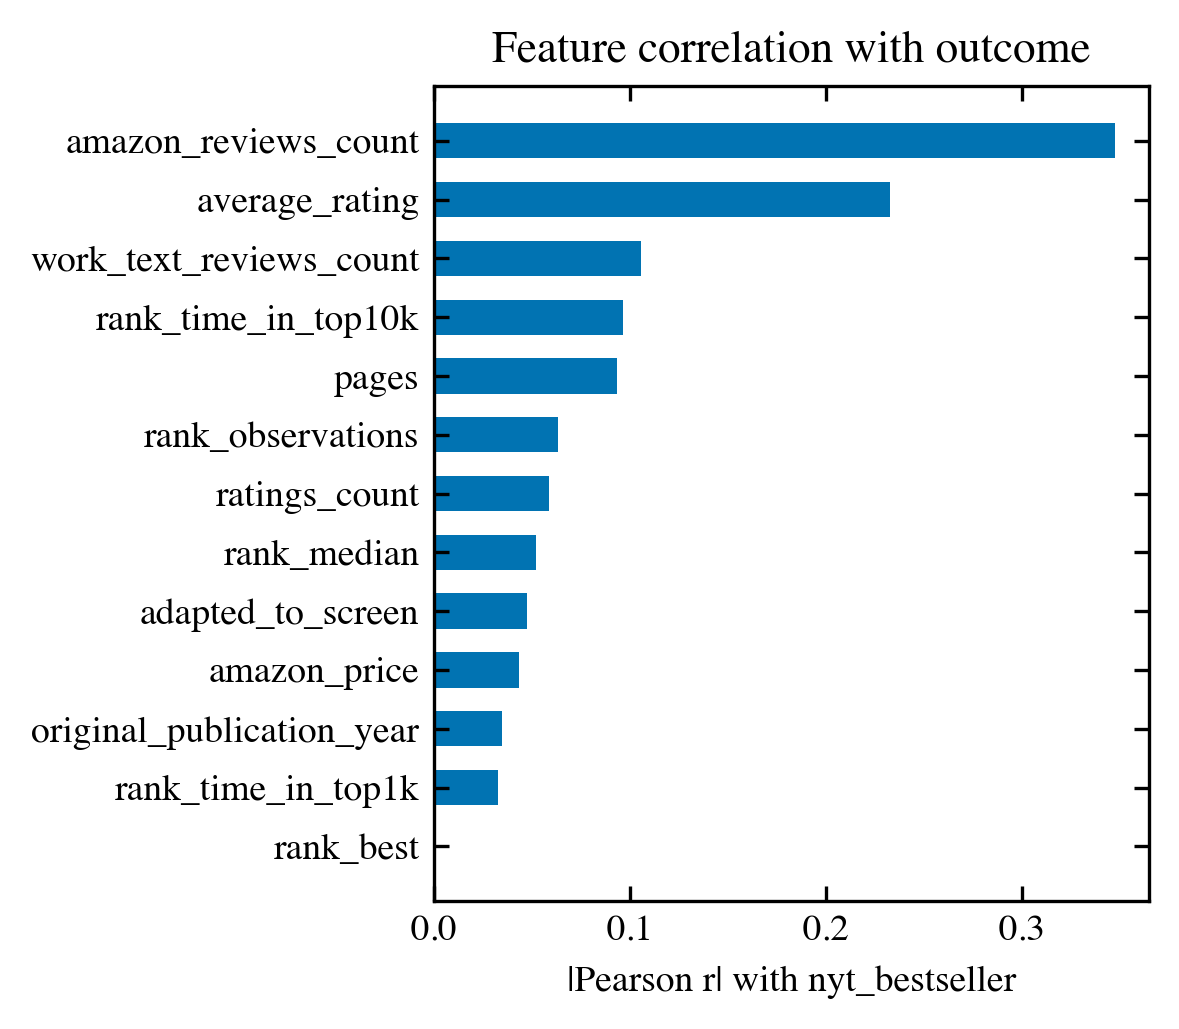

amazon_reviews_count         0.3474
average_rating               0.2328
work_text_reviews_count      0.1058
rank_time_in_top10k          0.0962
pages                        0.0931
rank_observations            0.0630
ratings_count                0.0584
rank_median                  0.0519
adapted_to_screen            0.0472
amazon_price                 0.0433
original_publication_year    0.0345
rank_time_in_top1k           0.0326
rank_best                    0.0006


In [16]:
# Point-biserial correlations with nyt_bestseller — ranked
target = 'nyt_bestseller'
feature_cols = [c for c in numeric_features if c != target]
pb_corrs = (
    canon[feature_cols + [target]]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.barh(pb_corrs.index, pb_corrs.values, color=COLOR_PALETTE[0], height=0.6)
ax.set_xlabel('|Pearson r| with nyt_bestseller')
ax.set_title('Feature correlation with outcome')
plt.tight_layout()
save_fig('03_feature_target_corr.png', FIGURES_DIR)
plt.show()

print(pb_corrs.sort_values(ascending=False).apply(lambda v: f'{v:.4f}').to_string())

## 8  Bestseller vs. non-bestseller: ratings and reviews

Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_bestseller_vs_ratings.png


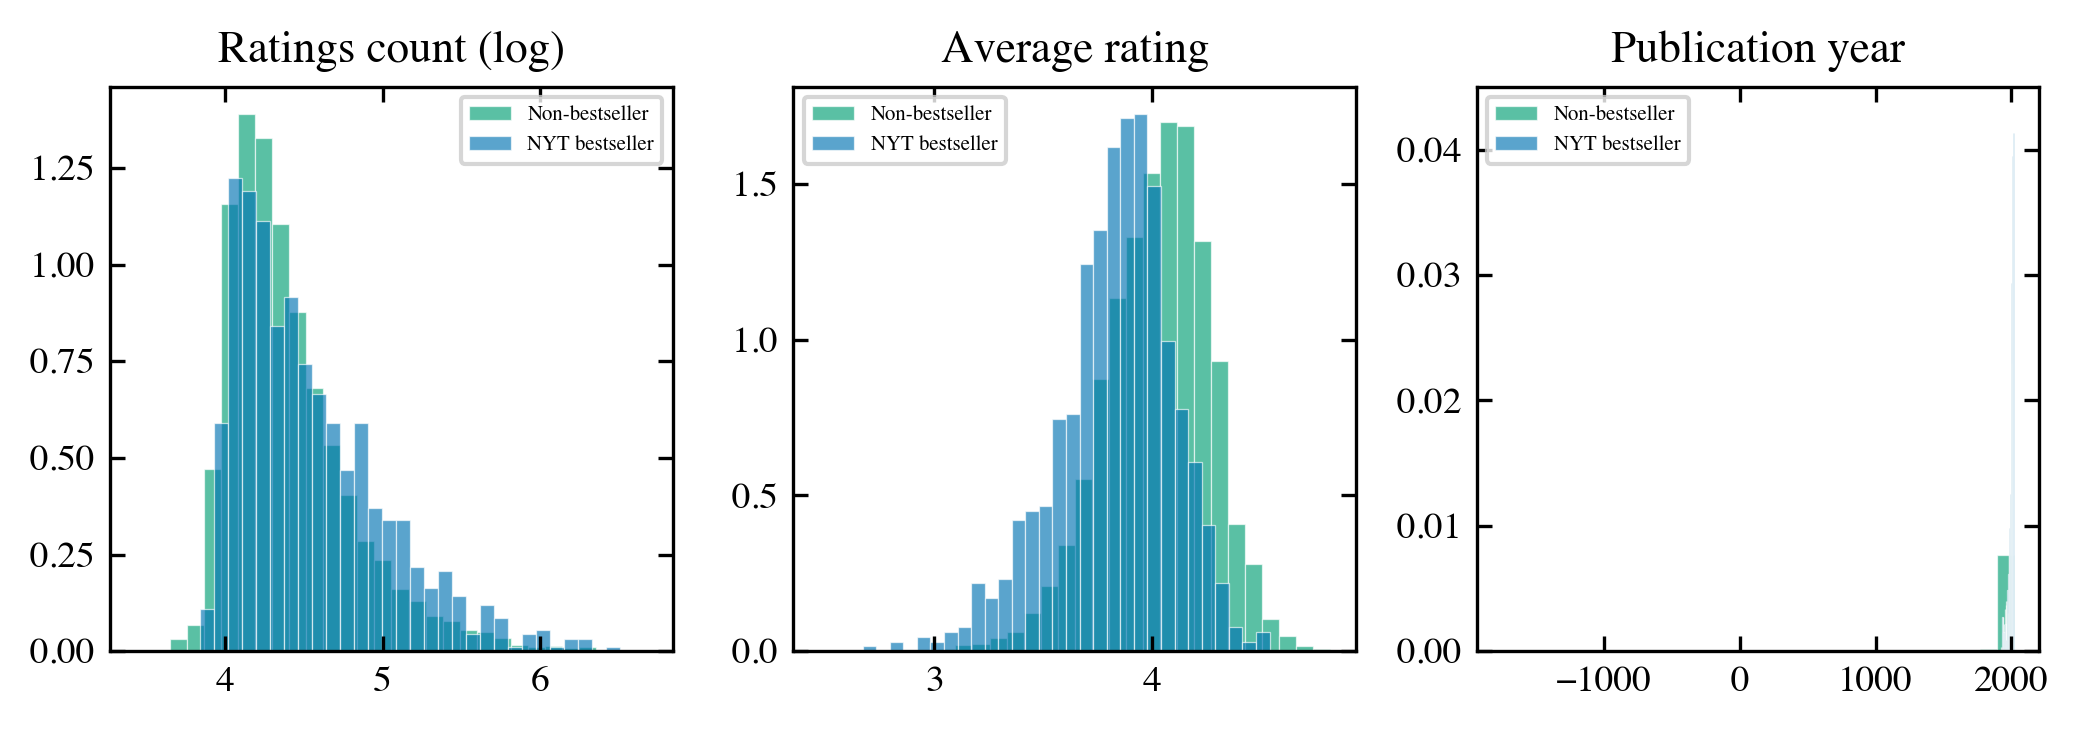

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

pairs = [
    ('ratings_count', 'Ratings count (log)', True),
    ('average_rating', 'Average rating', False),
    ('original_publication_year', 'Publication year', False),
]

for ax, (col, label, use_log) in zip(axes, pairs):
    for val, name, color in [(0, 'Non-bestseller', COLOR_PALETTE[2]),
                              (1, 'NYT bestseller', COLOR_PALETTE[0])]:
        data = canon.loc[canon['nyt_bestseller'] == val, col].dropna()
        data = np.log10(data + 1) if use_log else data
        ax.hist(data, bins=30, density=True, alpha=0.65, label=name,
                color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.legend(fontsize=5)

plt.tight_layout()
save_fig('03_bestseller_vs_ratings.png', FIGURES_DIR)
plt.show()

## 9  Language and publication year diagnostics

In [19]:
lang_counts = canon['language_code'].value_counts().head(10)
print("Language distribution (top 10):")
print(lang_counts.to_string())
print(f"\n'eng' share: {(canon['language_code'] == 'eng').mean():.1%}")
print(f"Any non-English bestseller: {((canon['nyt_bestseller'] == 1) & (canon['language_code'] != 'eng')).sum()}")

Language distribution (top 10):
language_code
eng    9680
ara      64
de       33
fre      25
es       21
ind      21
spa      20
fr       18
it       13
ger      13

'eng' share: 96.8%
Any non-English bestseller: 27


Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/03_bestseller_by_decade.png


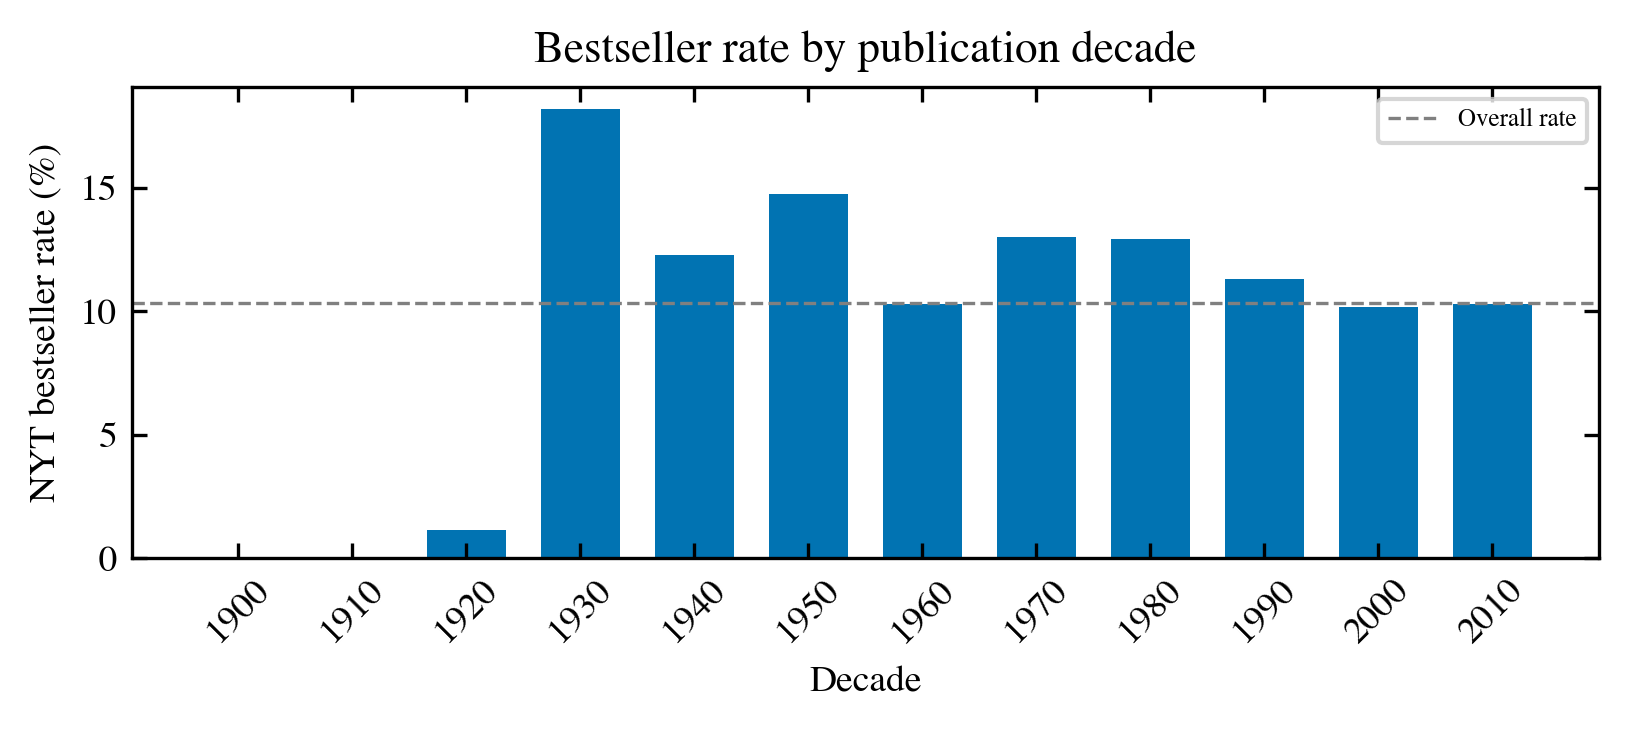

In [20]:
# Bestseller rate by decade
canon['decade'] = (canon['original_publication_year'] // 10 * 10).astype('Int64')
decade_stats = (
    canon.groupby('decade')
    .agg(n_books=('nyt_bestseller', 'count'),
         nyt_rate=('nyt_bestseller', 'mean'))
    .reset_index()
)
decade_stats = decade_stats[(decade_stats['decade'] >= 1900) & (decade_stats['n_books'] >= 20)]

fig, ax = plt.subplots(figsize=(5.5, 2.5))
ax.bar(decade_stats['decade'].astype(str), decade_stats['nyt_rate'] * 100,
       color=COLOR_PALETTE[0], width=0.7)
ax.axhline(canon['nyt_bestseller'].mean() * 100, color='gray',
           linewidth=0.8, linestyle='--', label='Overall rate')
ax.set_xlabel('Decade')
ax.set_ylabel('NYT bestseller rate (%)')
ax.set_title('Bestseller rate by publication decade')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=6)
plt.tight_layout()
save_fig('03_bestseller_by_decade.png', FIGURES_DIR)
plt.show()

## 10  Summary statistics

In [21]:
print("=== Canonical table summary ===")
print(f"Total books:          {len(canon):,}")
print(f"NYT bestsellers:      {canon['nyt_bestseller'].sum():,} ({canon['nyt_bestseller'].mean():.1%})")
print(f"Adapted to screen:    {canon['adapted_to_screen'].sum():,} ({canon['adapted_to_screen'].mean():.1%})")
print(f"Both outcomes:        {((canon['nyt_bestseller']==1)&(canon['adapted_to_screen']==1)).sum():,}")
print()
print("=== Identifier coverage ===")
print(f"ISBN-10:   {canon['isbn10'].notna().mean():.1%}")
print(f"ISBN-13:   {canon['isbn13'].notna().mean():.1%}")
print(f"ASIN:      {canon['asin'].notna().mean():.1%}")
print()
print("=== Feature coverage ===")
for col in ['rank_best', 'amazon_reviews_count', 'amazon_price', 'publisher', 'description']:
    print(f"{col:<30} {canon[col].notna().mean():.1%}")
print()
print("=== Goodreads signal summary ===")
print(canon[['average_rating', 'ratings_count', 'work_text_reviews_count', 'pages']].describe().round(1))

=== Canonical table summary ===
Total books:          10,000
NYT bestsellers:      1,032 (10.3%)
Adapted to screen:    26 (0.3%)
Both outcomes:        10

=== Identifier coverage ===
ISBN-10:   93.0%
ISBN-13:   94.3%
ASIN:      8.2%

=== Feature coverage ===
rank_best                      7.8%
amazon_reviews_count           1.0%
amazon_price                   1.0%
publisher                      8.2%
description                    99.5%

=== Goodreads signal summary ===
       average_rating  ratings_count  work_text_reviews_count   pages
count         10000.0        10000.0                  10000.0  9927.0
mean              4.0        54001.2                   2920.0   359.4
std               0.3       157370.0                   6124.4   216.9
min               2.5         2716.0                      3.0     0.0
25%               3.8        13568.8                    694.0   250.0
50%               4.0        21155.5                   1402.0   336.0
75%               4.2        41053.5